# Relatedness
Using output from [variant_calling.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/variant_calling/variant_calling.ipynb), I'm going to visualize the relatedness between my samples to determine population structure.

## 0. load libraries

In [2]:
library(tidyverse)
library(pheatmap)

## 1. read csv

this file was generated using [`vcftools`](https://vcftools.github.io/man_latest.html) and the -relatedness2 flag

In [14]:
rel <- read.csv('/scratch4/workspace/julia_mcdonough_student_uml_edu-novogene_dwnld/gatk/filtered/final_wMAF.relatedness2', sep ='\t')
head(rel)

,INDV1,INDV2,N_AaAa,N_AAaa,N1_Aa,N2_Aa,RELATEDNESS_PHI
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>
1,B1_B1_O01_gi,B1_B1_O01_gi,14314,0,14314,14314,0.50000000
2,B1_B1_O01_gi,B1_Nu_O03_gi,4732,2835,14314,13640,-0.03355510
3,B1_B1_O01_gi,B1_W5_O50_gi,4660,2855,14314,14801,-0.03606390
4,B1_B1_O01_gi,B2_B5_O51_gi,4628,2819,14314,13556,-0.03623970
5,B1_B1_O01_gi,B2_C4_O40_gi,5531,2830,14314,16630,-0.00416882
6,B1_B1_O01_gi,B2_Nu_O12_gi,4794,2736,14314,13269,-0.02458040


the RELATEDNESS_PHI column is the kinship coefficient

A negative kinship coefficient estimation indicates an unrelated relationship.

an estimated kinship coefficient range >0.354, [0.177, 0.354], [0.0884, 0.177] and [0.0442, 0.0884] corresponds to duplicate/MZ twin, 1st-degree, 2nd-degree, and 3rd-degree relationships respectively


## 2. visualizations

### geom_tile

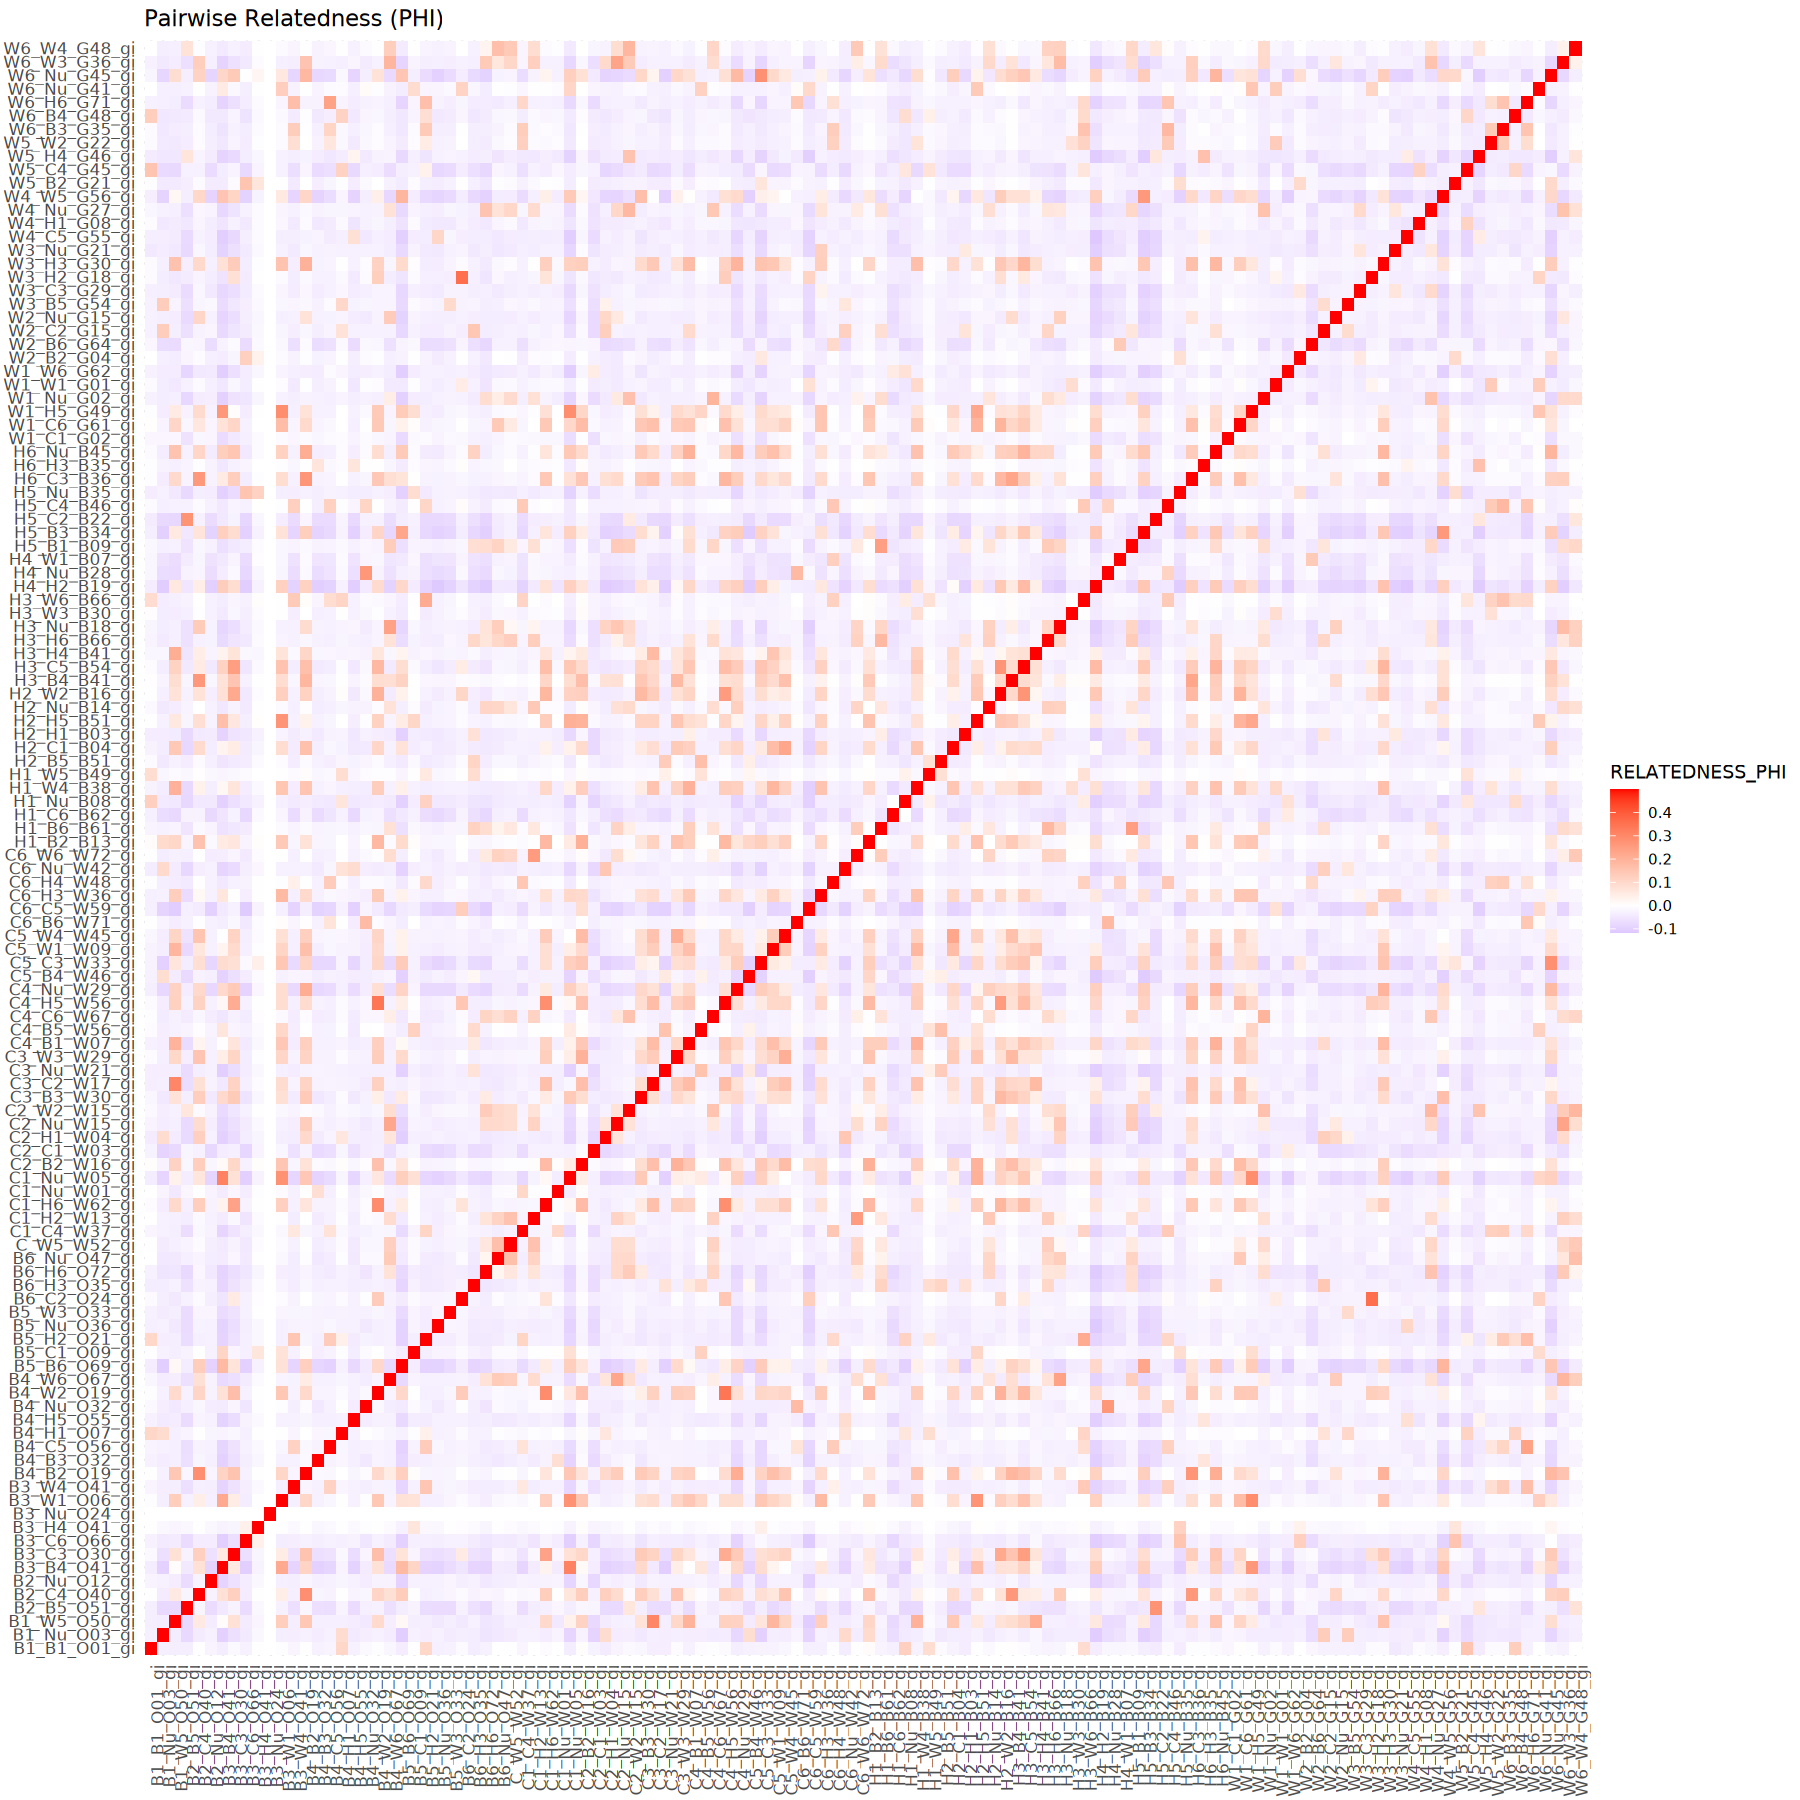

In [15]:
options(repr.plot.height = 15, repr.plot.width = 15)

ggplot(rel, aes(x = INDV1, y = INDV2, fill = RELATEDNESS_PHI)) +
 geom_tile() +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 10),
        axis.text.y = element_text(size = 10)) +
  labs(title = "Pairwise Relatedness (PHI)", x = NULL, y = NULL)

### pheatmap

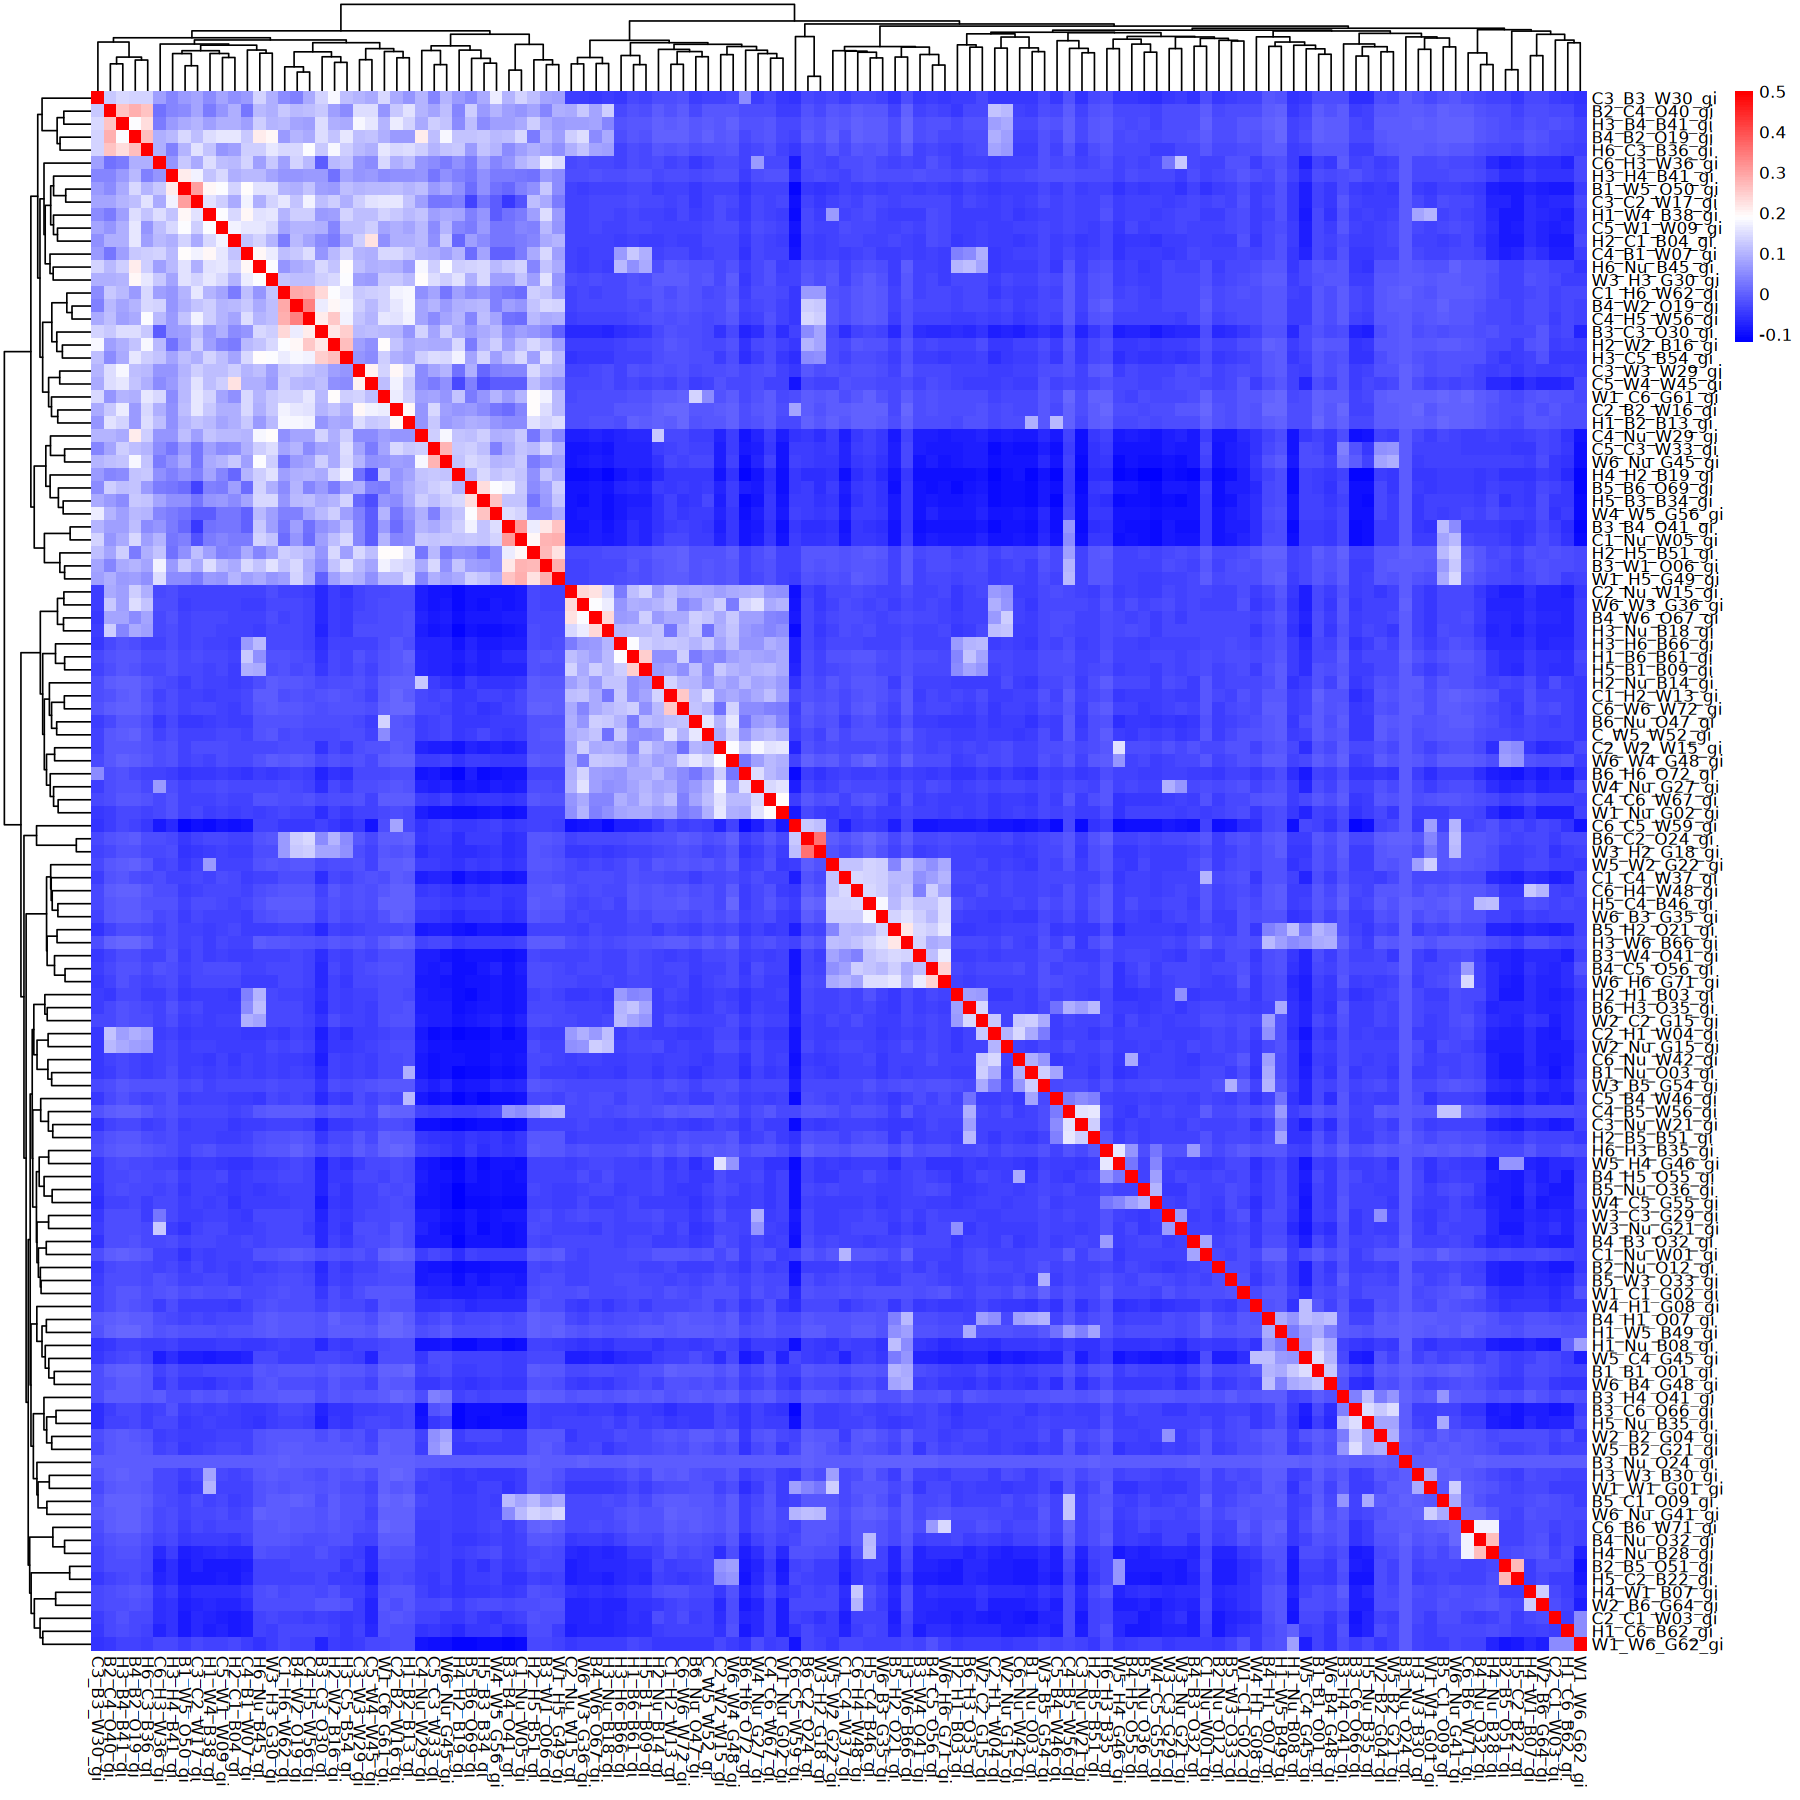

In [16]:
mat <- rel %>%
  select(INDV1, INDV2, RELATEDNESS_PHI) %>%
  pivot_wider(names_from = INDV2, values_from = RELATEDNESS_PHI) %>%
  tibble::column_to_rownames("INDV1") %>%
  as.matrix()

pheatmap(mat,
         clustering_method = "average",
         color = colorRampPalette(c("blue", "white", "red"))(100))

according to online talk, a negative kinship coefficient means the samples are unrelated - so we see some clustering of related indiviudals in red, but most samples are not related to each other

which is surprising?? I would expect the samples to be more related